In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from sklearn.model_selection import train_test_split

In [ ]:
from tensorflow import keras

# Load Reuters dataset
reuters = keras.datasets.reuters

(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

x_train = pad_sequences(x_train, maxlen=100, padding='post')
x_test = pad_sequences(x_test, maxlen=100, padding='post')

print(x_train.shape)
print(x_test.shape)

(8982, 100)
(2246, 100)


In [ ]:
print(x_train.shape)

(8982, 100)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),
    Bidirectional(LSTM(64)),
    Dense(32, activation='relu'),
    Dense(46, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.5106 - loss: 1.9754 - val_accuracy: 0.5659 - val_loss: 1.7123
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 143ms/step - accuracy: 0.6290 - loss: 1.5083 - val_accuracy: 0.6175 - val_loss: 1.5349
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 142ms/step - accuracy: 0.6919 - loss: 1.2583 - val_accuracy: 0.6514 - val_loss: 1.4080
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step - accuracy: 0.7339 - loss: 1.0578 - val_accuracy: 0.6554 - val_loss: 1.3860
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step - accuracy: 0.7760 - loss: 0.8800 - val_accuracy: 0.6670 - val_loss: 1.3763
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step - accuracy: 0.8130 - loss: 0.7273 - val_accuracy: 0.6616 - val_loss: 1.4220
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 39s 139ms/step - accuracy: 0.8430 - loss: 0.6054 - val_accuracy: 0.6781 - val_loss: 1.5099
Epoch 8/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 43s 148ms/step - accuracy: 0.8660 - loss: 0

In [ ]:
predictions = model.predict(x_test)

# Convert probabilities to class labels
predicted_classes = (predictions > 0.5).astype(int)

print(predicted_classes[:10])

71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
[[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0

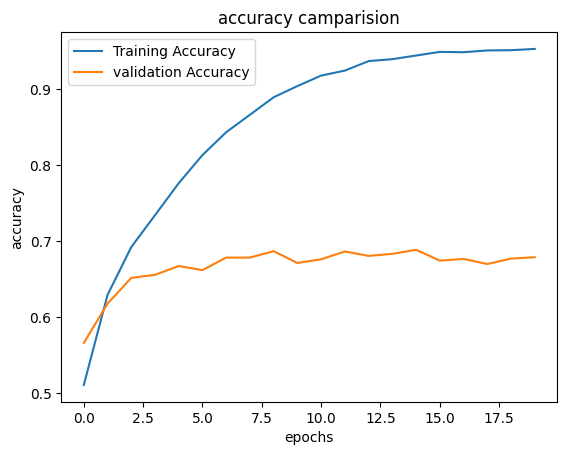

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.title("accuracy camparision")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

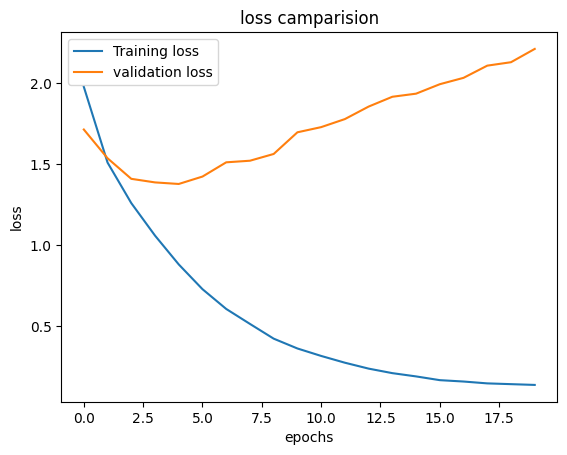

In [ ]:
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.title("loss camparision")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()